In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

In [2]:
X_train, X_test, y_train, y_test, X, y = joblib.load("../Data/preprocessing_all_info.joblib")

In [3]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Дерево 1

In [4]:
model_1 = XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=5, sumsample=0.7, colsample_bytree=0.7)

In [5]:
model_1.fit(X_train, y_train)

c:\Users\danil\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:37:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "sumsample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [6]:
y_pred = model_1.predict(X_test)
MSE = mean_squared_error(y_pred, y_test)
MAE = mean_absolute_error(y_pred, y_test)
RMSE = np.sqrt(MSE)
R = r2_score(y_test, y_pred)

print(f"MAE: {MAE}, MSE: {MSE}, RMSE: {RMSE}, R: {R}")

MAE: 0.6573516117158522, MSE: 0.8149714555919934, RMSE: 0.9027576948395363, R: 0.7355731497340552


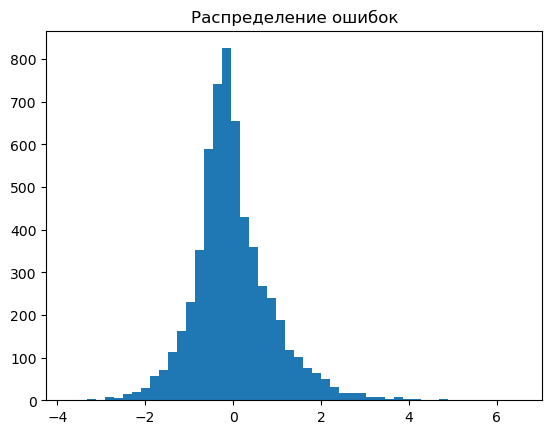

In [7]:
residuals = y_test - y_pred
plt.hist(residuals, bins=50)
plt.title('Распределение ошибок')
plt.show()

In [8]:
print(model_1.predict(X) ,y[0])

[3.5186136] 11.350418300109132


Не будем долго радоваться добавим регуляризацию

### Дерево 2

In [9]:
model_2 = XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=5, sumsample=0.7, colsample_bytree=0.7, l2_leaf_reg=20)

In [10]:
model_2.fit(X_train, y_train)

c:\Users\danil\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:37:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "l2_leaf_reg", "sumsample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None, l2_leaf_reg=20,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, ...)

In [11]:
y_pred = model_2.predict(X_test)
MSE = mean_squared_error(y_pred, y_test)
MAE = mean_absolute_error(y_pred, y_test)
RMSE = np.sqrt(MSE)
R = r2_score(y_test, y_pred)

print(f"MAE: {MAE}, MSE: {MSE}, RMSE: {RMSE}, R: {R}")

MAE: 0.6573516117158522, MSE: 0.8149714555919934, RMSE: 0.9027576948395363, R: 0.7355731497340552


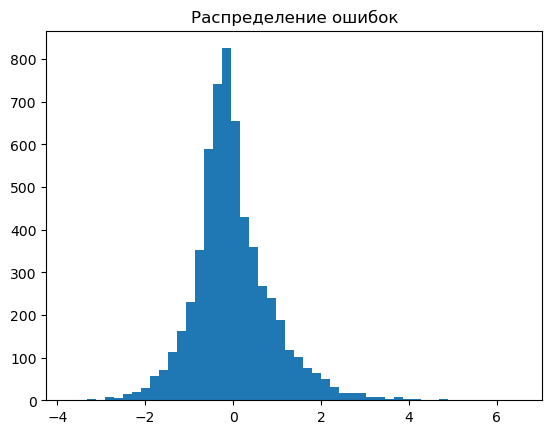

In [12]:
residuals = y_test - y_pred
plt.hist(residuals, bins=50)
plt.title('Распределение ошибок')
plt.show()

In [13]:
print(model_2.predict(X) ,y[0])

[3.5186136] 11.350418300109132


Регуляризация не помогла

### Дерево 3

In [14]:
model_3 = XGBRegressor(n_estimators=500, learning_rate=0.01, max_depth=5, sumsample=0.7, colsample_bytree=0.7, l2_leaf_reg=20, iterations=100000)

In [15]:
model_3.fit(X_train, y_train)

c:\Users\danil\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:37:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "iterations", "l2_leaf_reg", "sumsample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             iterations=100000, l2_leaf_reg=20, learning_rate=0.01,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, ...)

In [16]:
y_pred = model_3.predict(X_test)
MSE = mean_squared_error(y_pred, y_test)
MAE = mean_absolute_error(y_pred, y_test)
RMSE = np.sqrt(MSE)
R = r2_score(y_test, y_pred)

print(f"MAE: {MAE}, MSE: {MSE}, RMSE: {RMSE}, R: {R}")

MAE: 0.6686228244133702, MSE: 0.831422776591409, RMSE: 0.9118238736682699, R: 0.7302353296610448


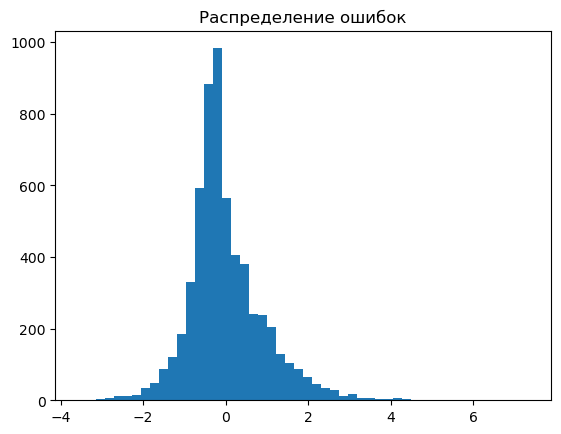

In [17]:
residuals = y_test - y_pred
plt.hist(residuals, bins=50)
plt.title('Распределение ошибок')
plt.show()

In [18]:
print(model_3.predict(X) ,y[0])

[4.384209] 11.350418300109132


Итерации и понижение скорости обучения ничего не дало

### Дерево 4

In [19]:
model_4 = XGBRegressor(n_estimators=1000, learning_rate=0.1, max_depth=5, sumsample=0.7, colsample_bytree=0.7, l2_leaf_reg=20)

In [20]:
model_4.fit(X_train, y_train)

c:\Users\danil\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:37:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "l2_leaf_reg", "sumsample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None, l2_leaf_reg=20,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, ...)

In [21]:
y_pred = model_4.predict(X_test)
MSE = mean_squared_error(y_pred, y_test)
MAE = mean_absolute_error(y_pred, y_test)
RMSE = np.sqrt(MSE)
R = r2_score(y_test, y_pred)

print(f"MAE: {MAE}, MSE: {MSE}, RMSE: {RMSE}, R: {R}")

MAE: 0.6639512376722397, MSE: 0.8265626198759284, RMSE: 0.9091548932255319, R: 0.7318122633355375


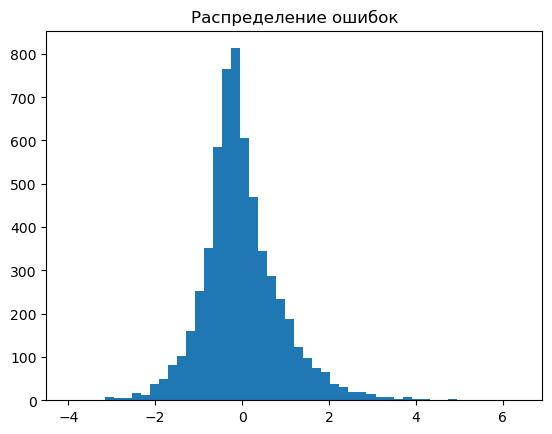

In [22]:
residuals = y_test - y_pred
plt.hist(residuals, bins=50)
plt.title('Распределение ошибок')
plt.show()

In [23]:
print(model_4.predict(X) ,y[0])

[3.4632537] 11.350418300109132


Все равно хуже

### Дерево 5

In [24]:
model_5 = XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=5, sumsample=0.9, colsample_bytree=0.9)

In [25]:
model_5.fit(X_train, y_train)

c:\Users\danil\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:37:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "sumsample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [26]:
y_pred = model_5.predict(X_test)
MSE = mean_squared_error(y_pred, y_test)
MAE = mean_absolute_error(y_pred, y_test)
RMSE = np.sqrt(MSE)
R = r2_score(y_test, y_pred)

print(f"MAE: {MAE}, MSE: {MSE}, RMSE: {RMSE}, R: {R}")

MAE: 0.6610874236887905, MSE: 0.8239768215340476, RMSE: 0.9077316902775002, R: 0.7326512553103789


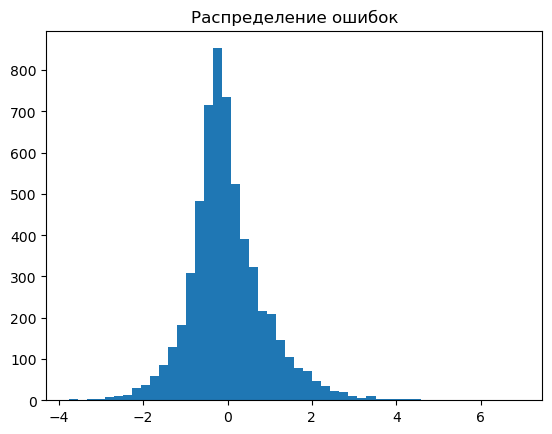

In [27]:
residuals = y_test - y_pred
plt.hist(residuals, bins=50)
plt.title('Распределение ошибок')
plt.show()

In [28]:
print(model_5.predict(X) ,y[0])

[4.3266587] 11.350418300109132


Видимо изначально уже было идеально